## Telco Customer Churn Analysis 

#### Problem Statement 
Customer churn is a critical challenge in the telecommunications industry, as losing customers leads to reduced revenue, increased acquisition costs, and lower long-term profitability. Despite having access to large volumes of customer data, the company lacks a clear understanding of the factors that drive customers to leave.

There is a need to analyze customer behavior, service usage, billing patterns, and contract types to identify the key drivers of churn. Without this understanding, the company cannot effectively design strategies to improve customer retention or target high-risk customers.

Therefore, this project aims to perform an Exploratory Data Analysis (EDA) on the telecom customer dataset to:

understand the distribution of customer characteristics,
identify patterns and relationships between customer attributes and churn,
determine the key factors influencing customer churn,
and provide data-driven insights that can support better business decisions and improve customer retention strategies.

#### Data Description
- Column
- gender: Whether the customer is a male or a female
- SeniorCitizen: Whether the customer is a seniorcitizen or not (1, 0)1 = Yes, 0 = No
- Partner: Whether the customer has a partner or not (Yes, No)
- Dependents: Whether the customer has dependents or not (Yes, No)
- tenure: Number of months the customer has stayed with the company
- Contract: Month-to-month / One year / Two year
- PaymentMethod: The method the customer uses to pay their bills.
- MonthlyCharges: Numeric
- TotalCharges: Numeric
- Churn	                    Yes/No (Target)
- TechSupport, OnlineSecurity, StreamingTV, etc.	Service-related features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
print("Successfully Installed")

df = pd.read_csv("TelcoCustomerChurn.csv")

Successfully Installed


In [2]:
df.shape

(7043, 21)

- In this dataset, we havre 7043 rows and 21 columns

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop("customerID", axis=1)

### Univariate Analysis 

In [11]:
#Check the distribution of Churn
df["Churn"].value_counts()
#Checking its percentage.
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [38]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

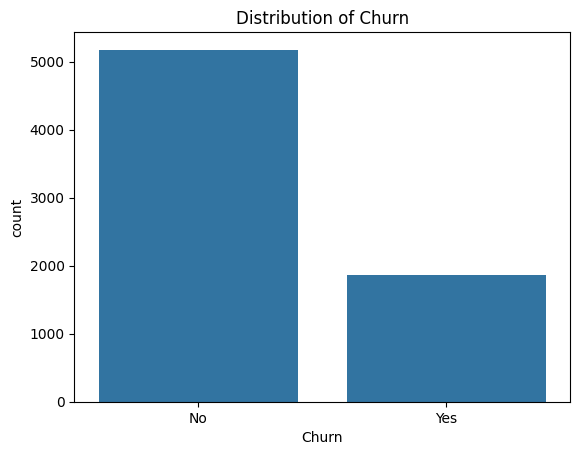

In [2]:
#Churn Distribution
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.show()

- The number of customers who did not churn is much higher than those who churned.
- This shows that the company retained most of its customers, but the number of churned customers is still large enough to be a concern.

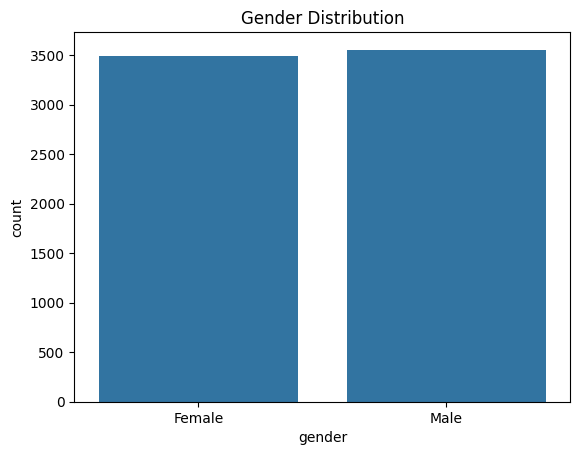

In [13]:
#Gender distribution
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

- Both gender are almost equally distributed in the dataset.

In [14]:
#Checking gender distribution 
df["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [15]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

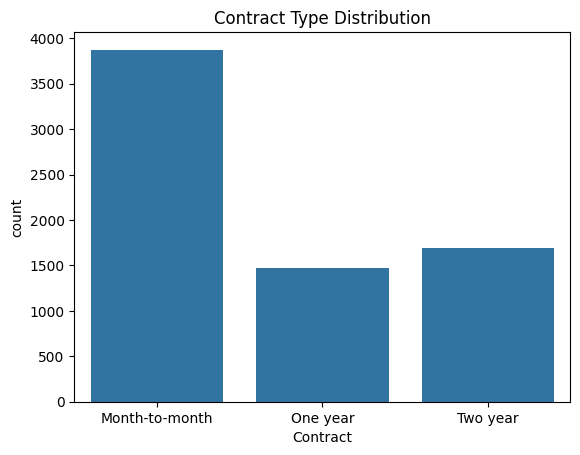

In [16]:
#COntract distribution
sns.countplot(x="Contract", data=df)
plt.title("Contract Type Distribution")
plt.show()

- Month-to-month contract customers are the largest group.
- One-year contract customers are fewer.
- Two-year contract customers are slightly more than one-year customers, but still far below month-to-month.

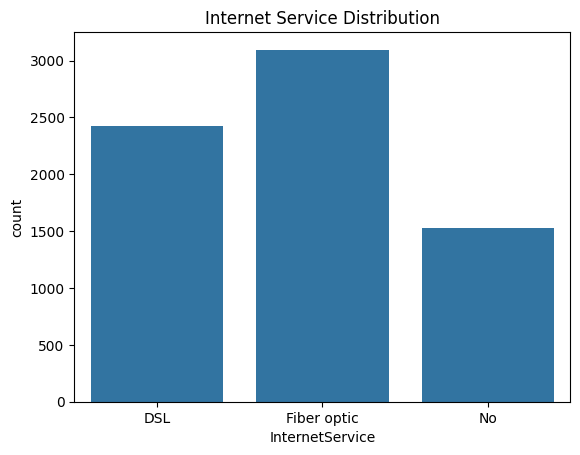

In [17]:
#internet service distribution 
sns.countplot(x="InternetService", data=df)
plt.title("Internet Service Distribution")
plt.show()

- Fiber optic users are the largest group.
- DSL users are the second largest group.
- Customers with no internet service are the fewest.
- Internet service is a major product in this company.
- Since fiber optic has the highest number of users, any issue affecting this service can strongly affect churn.

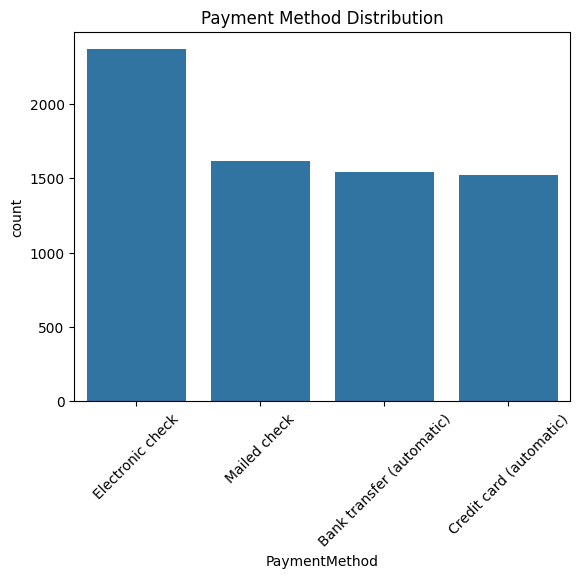

In [40]:
#Payment method distribution
sns.countplot(x="PaymentMethod", data=df)
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

- Electronic check is the most common payment method.
- Mailed check, bank transfer (automatic), and credit card (automatic) are relatively close in size, but all are lower than electronic check.

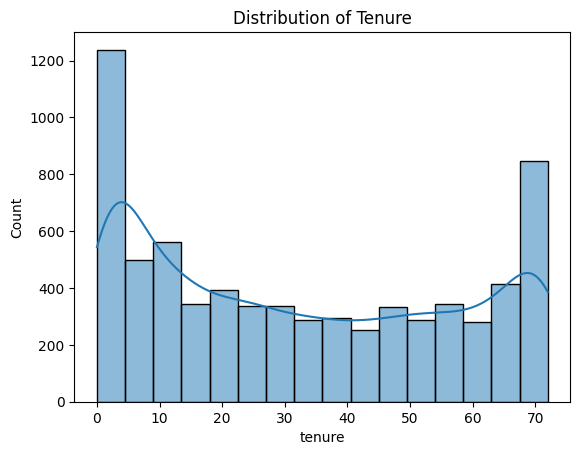

<Axes: xlabel='tenure'>

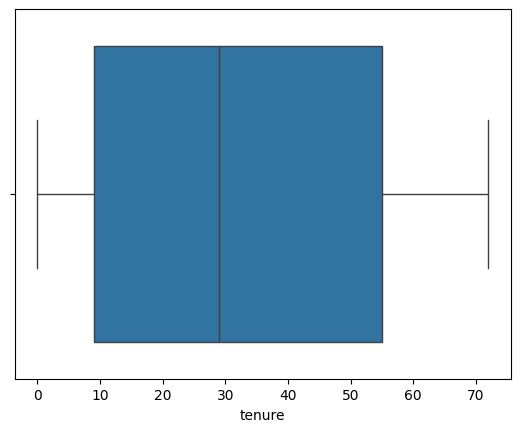

In [19]:
#plot distribution of tenure 
sns.histplot(df["tenure"], kde=True)
plt.title("Distribution of Tenure")
plt.show()
sns.boxplot(x=df["tenure"])

- The tenure distribution shows many customers at the very low end and also a noticeable number at the high end.
- This suggests the company has both many new customers and many long-term customers.
- The middle tenure range is less concentrated than the extremes.
- The presence of many low-tenure customers may indicate a risk area, because newer customers are usually more likely to churn.

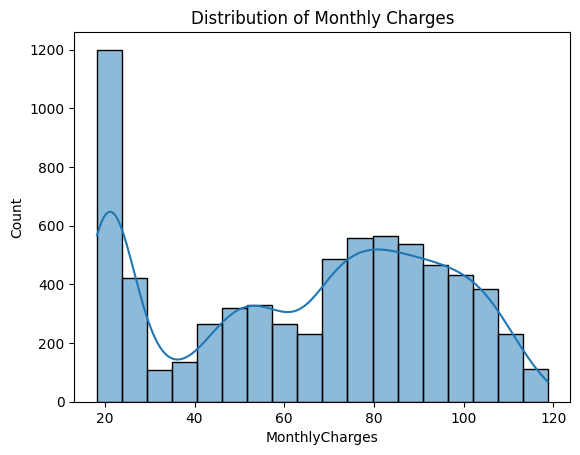

<Axes: xlabel='MonthlyCharges'>

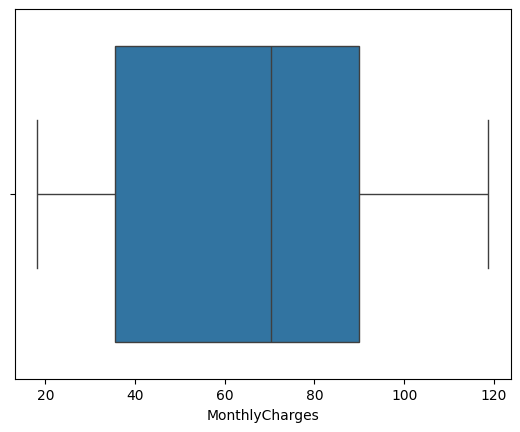

In [20]:
#Distribution of monthly charges 
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()
sns.boxplot(x=df["MonthlyCharges"])

- The distribution is not uniform, showing that customers pay different amounts depending on their services.
- The company offers service plans with varying prices.
- Since many customers fall into medium-to-high monthly charges, pricing may be an important factor in churn.

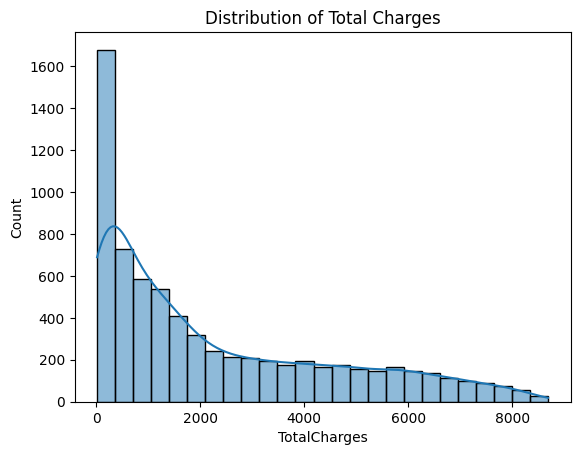

<Axes: xlabel='TotalCharges'>

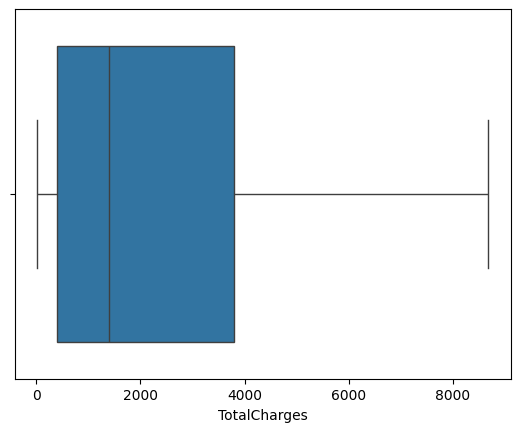

In [21]:
#Distribution of total charges 
sns.histplot(df["TotalCharges"], kde=True)
plt.title("Distribution of Total Charges")
plt.show()
sns.boxplot(x=df["TotalCharges"])


- Total charges are right-skewed, meaning many customers have low total charges, while fewer customers have very high total charges.
- Customers with low total charges are likely newer customers or customers with lower service usage.
- Customers with high total charges are likely long-term customers.

### Bivariate analysis 


In [22]:
#Churn by gender 
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


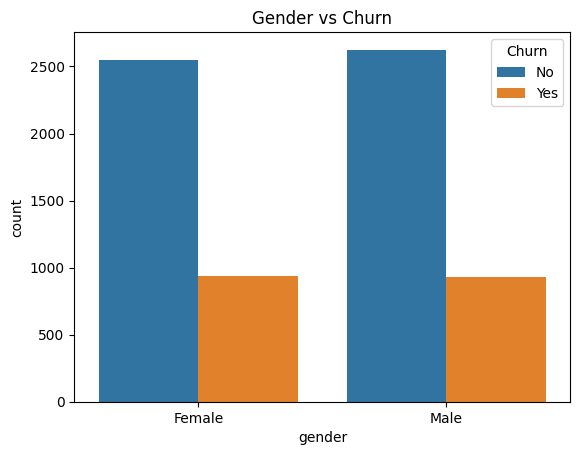

In [23]:
sns.countplot(x="gender",hue="Churn",  data=df)
plt.title("Gender vs Churn")
plt.show()

In [24]:
#Churn by contract type 
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


- The number of churned customers is almost the same across both genders.
- There is no clear visible difference suggesting one gender churns much more than the other.
- Gender does not appear to be a major driver of churn in this dataset.

In [25]:
#Checking the contract type churn rate.
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


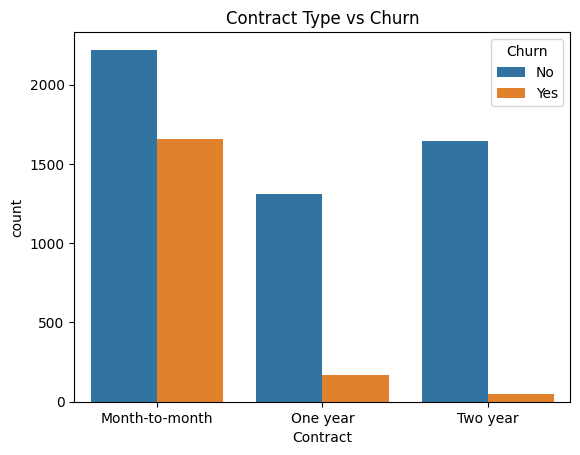

In [26]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

- Month-to-month customers have by far the highest churn count.
- One-year and Two-year customers have much lower churn.
- Two-year customers have the lowest churn.
- Contract type is one of the strongest indicators of churn.
- Customers on short-term contracts are much more likely to leave than customers on long-term contracts

In [27]:
#Churn by Internet service 
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [28]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


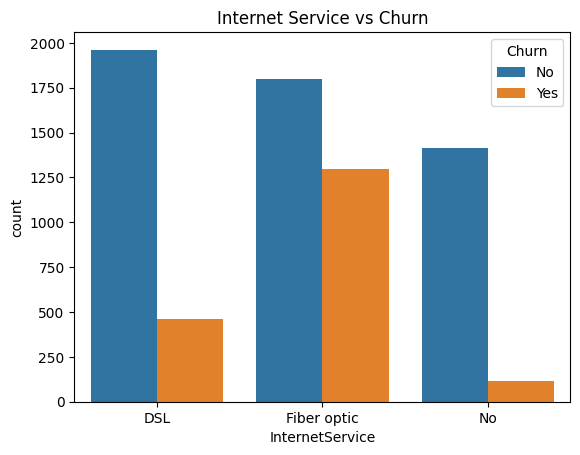

In [29]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

- Fiber optic customers are more likely to leave.
- This could be linked to price, expectations, service quality, or customer dissatisfaction.

In [30]:
#Churn by payment method 
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [31]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


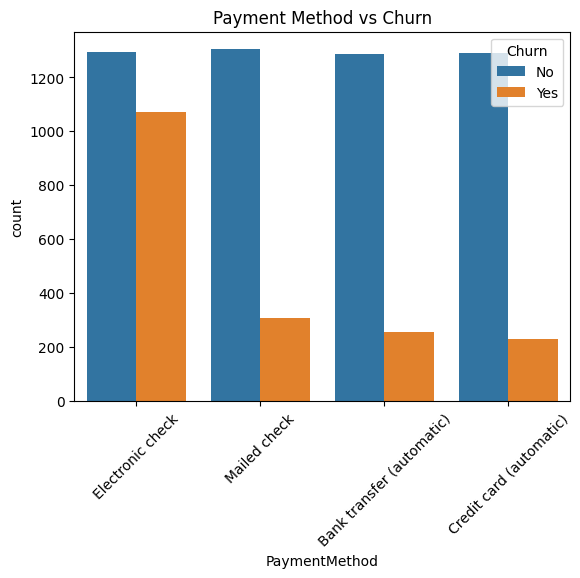

In [32]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

- Customers using Electronic check have the highest churn count.
- Customers using automatic payment methods such as bank transfer and credit card show lower churn.
- Mailed check customers also churn less than electronic check users.
- Payment method appears to be related to customer stability.
- Customers who use automatic payment methods may be more committed or experience fewer payment-related issues.

### Multivariate Analysis

In [33]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
#correlation shows the strength and direction of a relationship.

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


### Correlation heatmap 

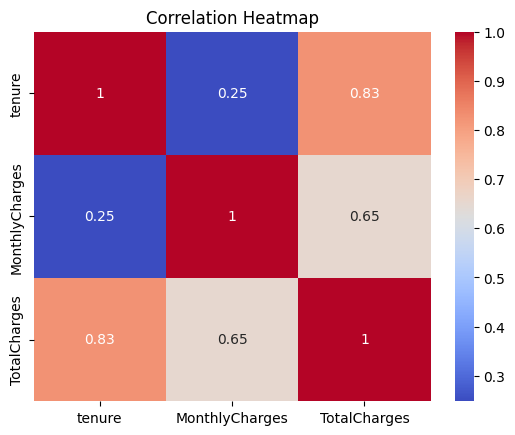

In [34]:
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- Tenure and TotalCharges have a strong positive correlation (0.83).
- MonthlyCharges and TotalCharges have a moderate positive correlation (0.65).
- Tenure and MonthlyCharges have a weak positive correlation (0.25)
- Customers who stay longer naturally accumulate higher total charges.
- Higher monthly charges also contribute to higher total charges, but not as strongly as tenure does.
- Monthly charges and tenure are not strongly related, meaning customers can stay long without necessarily paying very high monthly fees.

### Final Summary table 

In [35]:
#Churn rate by contract  
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


- Month-to-month customers are far more likely to churn than customers on yearly contracts.
- Two-year contracts have the strongest retention.
- This confirms that long-term contracts greatly reduce churn

In [36]:
#Churn by INternet service 
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


- Fiber optic customers are the most likely to churn.
- DSL customers are more stable than fiber optic customers.
- Customers with no internet service are the least likely to churn

In [37]:
#Churn rate by paymentmethod 
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


- Electronic check users are the most likely to churn.
- Automatic payment users are the least likely to churn.
- This suggests that customers with more automated and stable payment behavior tend to stay longer.

### Overall Observation

- **Customer churn is a real business issue:** 
Although most customers stayed, a substantial number left, meaning churn is large enough to affect company performance.
- **Contract type is the strongest churn factor:**
Month-to-month customers are far more likely to churn than one-year or two-year customers.
- **Fiber optic customers are a major risk group:** 
They form the largest internet service group and also show the highest churn rate, which makes them especially important to investigate.
- **Electronic check users are the most likely to churn:** 
This group has the highest churn rate among payment methods, suggesting that payment behavior is linked to customer retention.
- **Gender does not appear to strongly influence churn:** 
Male and female customers behave similarly with respect to churn.
- **Tenure plays an important role in customer stability:** 
The dataset contains many low-tenure customers and many long-tenure customers, and total charges rise strongly with tenure.
- **Pricing may contribute to churn:** 
Since monthly charges vary widely and fiber optic customers churn more, high-value service plans may need review.

#### Recommendations 
- Encourage customers to move to long-term contracts.
- Investigate the high churn among fiber optic customers.
- Promote automatic payment methods
- Focus on new customers early.
- Review pricing structure for high-service customers.